In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from jax import random, vmap, jit
from functools import partial

KEY = random.PRNGKey(2026)

# Consistent plot style
plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "axes.grid": True,
    "axes.grid.which": "major",
    "grid.alpha": 0.3,
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 100,
})

# Color palette used throughout
C_BLUE   = "#2166AC"
C_RED    = "#B2182B"
C_GREEN  = "#1B7837"
C_ORANGE = "#E08214"
C_PURPLE = "#6A3D9A"


# Question 1 — Reject-ABC

## Goal

We want to estimate $\theta = (\mu,\sigma^2)$ from observed data $y^\star = (y_1^\star,\dots,y_n^\star)$, where

$$
Y_i = \sum_{\ell=1}^{L}\exp(X_{i,\ell}),
\qquad
X_{i,\ell}\overset{iid}{\sim}\mathcal N(\mu,\sigma^2).
$$

As the project suggests, we first generate synthetic data from known true parameters ($L=10$, $\mu_0=0$, $\sigma_0=0.3$, so $\sigma_0^2 = 0.09$) and then see if Reject-ABC can recover them.

## Why we use ABC here

We can't evaluate the likelihood because the density of $Y_i = \exp(X_{i,1})+\cdots+\exp(X_{i,L})$ has no closed form. But we *can* simulate fake data for any proposed $\theta$. That's exactly the setting where ABC works:

- we can't compute $p(y^\star\mid\theta)$,
- but we can draw $y^{\text{sim}}\sim p(\cdot\mid\theta)$,
- and compare $y^{\text{sim}}$ to $y^\star$ using some distance.

## The ABC posterior

The idea is simple: accept a proposed $\theta^*$ if the simulated data is close enough to the real data,

$$
d(y^{\text{sim}},\,y^\star)\leq \varepsilon.
$$

This gives us samples from the ABC posterior

$$
p_\varepsilon(\theta\mid y^\star)
\;\propto\;
p(\theta)\;
\mathbb P_\theta
\!\left[
d(Y^{\text{sim}},\,y^\star)\leq \varepsilon
\right].
$$

Small $\varepsilon$ means a better approximation to the true posterior, but fewer proposals get accepted. Large $\varepsilon$ is cheap but gives a rougher approximation.

## Prior

Following the project statement, we use

$$
\mu \sim \mathcal N(0,s^2),
\qquad
\eta = \log(\sigma^2)\sim \mathcal N(0,t^2),
$$

which ensures $\sigma^2 = e^\eta > 0$. One thing to keep in mind: the true value $\log(\sigma_0^2) = \log(0.09) \approx -2.41$ is pretty far from the prior center at $\eta = 0$ (i.e. $\sigma^2 = 1$). So if $t$ is small, the prior barely covers the truth. We'll come back to this.

## Choice of distance

The project says to use the MEWE distance from Bernton et al. (2017). To be precise, MEWE stands for "minimum expected Wasserstein estimator" — it's actually an estimation procedure, not a distance. The distance it relies on is the **1-Wasserstein distance**.

In our case the data is one-dimensional and both samples have the same size $n$, so $W_1$ has a simple form: sort both samples and take the mean absolute difference,

$$
W_1(y^{\text{sim}},\,y^\star)
= \frac{1}{n} \sum_{i=1}^{n} \left| y^{\text{sim}}_{(i)} - y^\star_{(i)} \right|.
$$

This is nice because it compares the full empirical distributions without needing to pick summary statistics, and it only costs $O(n\log n)$ to compute (just the sorting).

## Reject-ABC algorithm

Here is the algorithm we implement:

$$
\boxed{
\begin{aligned}
&\textbf{Reject-ABC} \\[4pt]
&\text{Set } \texttt{accepted} = \emptyset.\\[2pt]
&\textbf{while } |\texttt{accepted}| < N \textbf{ do:}\\
&\quad 1.\;\text{Draw } \theta^* = (\mu^*,\,\sigma^{2*}) \text{ from the prior } p(\theta).\\
&\quad 2.\;\text{Simulate fake data under } \theta^*\text{:}\\
&\qquad\qquad X^*_{i,\ell} \sim \mathcal N(\mu^*,\,\sigma^{2*}),
\quad
Z^*_i = \sum_{\ell=1}^{L}\exp(X^*_{i,\ell}),
\quad i=1,\dots,n.\\
&\quad 3.\;\text{Compute the distance } d(z^*,\,y^\star) = W_1(z^*,\,y^\star).\\
&\quad 4.\;\textbf{if } d(z^*,\,y^\star) \leq \varepsilon\text{:}\\
&\qquad\qquad \texttt{accepted} = \texttt{accepted}\cup\{\theta^*\}.\\
&\textbf{return } \texttt{accepted}.
\end{aligned}
}
$$

The accepted draws $\{\theta^{*(1)},\dots,\theta^{*(N)}\}$ are i.i.d. samples from the ABC posterior $p_\varepsilon(\theta\mid y^\star)$. We then estimate $\theta$ by the posterior mean, and quantify uncertainty with the posterior standard deviation and 95% credible intervals.

## Implementation

We need three helper functions: a simulator for the model, the $W_1$ distance, and a function to summarize the posterior.

In [2]:
def simulate_sum_lognormal(key, mu, sigma2, L, n):
    """
    Simulate n observations Y_i = sum_l exp(X_{i,l}), X_{i,l} ~ N(mu, sigma2).
    JAX version: key is a JAX PRNGKey.
    """
    X = mu + jnp.sqrt(sigma2) * random.normal(key, shape=(n, L))
    return jnp.sum(jnp.exp(X), axis=1)


@jit
def wasserstein1d(y_sim, y_obs_sorted):
    """
    1-Wasserstein distance between y_sim and a pre-sorted reference y_obs_sorted.
    Both must have the same length. JAX-jitted.
    """
    return jnp.mean(jnp.abs(jnp.sort(y_sim) - y_obs_sorted))


@partial(jit, static_argnums=(1, 4, 5))
def _batch_proposals(key, bs, s, t, n, L, y_obs_sorted):
    """
    Draw bs proposals from the prior, simulate one dataset each, and return
    their W1 distances to y_obs_sorted.

    Static args: bs (batch size), n (obs size), L (log-normals per obs).
    This function compiles once per unique (bs, n, L) triple and is shared
    across all reject_abc / prior_predictive_distances calls.

    Returns: mus (bs,), sigma2s (bs,), dists (bs,)
    """
    k_mu, k_eta, k_sim = random.split(key, 3)
    mus     = s * random.normal(k_mu,  shape=(bs,))
    sigma2s = jnp.exp(t * random.normal(k_eta, shape=(bs,)))
    keys_sim = random.split(k_sim, bs)

    def sim_one(k, mu, s2):
        X = mu + jnp.sqrt(s2) * random.normal(k, shape=(n, L))
        return jnp.sum(jnp.exp(X), axis=1)

    Y_sims = vmap(sim_one)(keys_sim, mus, sigma2s)          # (bs, n)
    dists  = vmap(lambda y: wasserstein1d(y, y_obs_sorted))(Y_sims)  # (bs,)
    return mus, sigma2s, dists


def posterior_summary(accepted, true_values=None):
    """Summarize ABC posterior. accepted has columns [mu, sigma2]."""
    if len(accepted) == 0:
        raise ValueError("No accepted draws.")
    names = ["mu", "sigma2"]
    rows = []
    for j, name in enumerate(names):
        col = accepted[:, j]
        row = {
            "parameter": name,
            "mean"     : f"{col.mean():.4f}",
            "median"   : f"{np.median(col):.4f}",
            "std"      : f"{col.std():.4f}",
            "q2.5%"    : f"{np.quantile(col, 0.025):.4f}",
            "q97.5%"   : f"{np.quantile(col, 0.975):.4f}",
        }
        if true_values is not None:
            row["true"] = f"{true_values[j]:.4f}"
        rows.append(row)
    return pd.DataFrame(rows)


## Synthetic observed data

We generate our "observed" dataset using the true parameters from the project statement.

In [3]:
n = 10000
L = 10
mu_true     = 0.0
sigma_true  = 0.3
sigma2_true = sigma_true**2

KEY, key_obs = random.split(KEY)
y_obs = np.array(simulate_sum_lognormal(key_obs, mu_true, sigma2_true, L, n))

print(f"n = {n},  L = {L}")
print(f"mu_true = {mu_true},  sigma2_true = {sigma2_true}")
print(f"Observed data: mean = {y_obs.mean():.2f}, std = {y_obs.std():.2f}")


n = 10000,  L = 10
mu_true = 0.0,  sigma2_true = 0.09
Observed data: mean = 10.45, std = 1.01


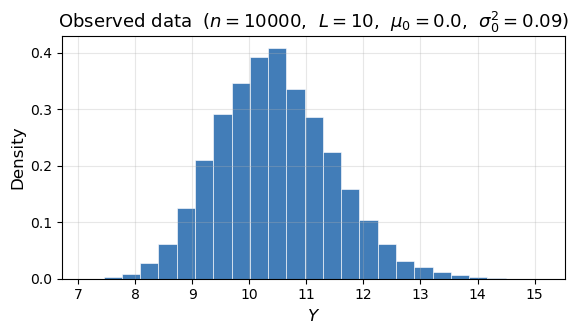

In [4]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(y_obs, bins=25, density=True, color=C_BLUE, edgecolor="white",
        alpha=0.85, linewidth=0.5)
ax.set_xlabel(r"$Y$")
ax.set_ylabel("Density")
ax.set_title(fr"Observed data  ($n={n}$,  $L={L}$,  $\mu_0={mu_true}$,  $\sigma_0^2={sigma2_true}$)")
plt.tight_layout()
plt.show()

In [19]:
def reject_abc(y_obs, L, epsilon, n_keep, s=1.0, t=1.0,
               max_proposals=500_000, seed=1234, batch_size=4096):
    """
    Reject-ABC for theta = (mu, sigma^2) — JAX batch version (jit + vmap).
    Prior: mu ~ N(0, s^2),  log(sigma^2) ~ N(0, t^2).

    Each iteration draws proposals in parallel via _batch_proposals
    (module-level jit+vmap, compiled once per unique batch size, n, L).
    The Python loop only handles the stopping rule.

    Reported proposal counts/rates are based on the number of proposals
    effectively examined until the n_keep-th accepted draw is reached.
    """
    key = random.PRNGKey(seed)
    n = len(y_obs)
    y_obs_sorted = jnp.sort(jnp.array(y_obs))

    acc_mu, acc_s2, acc_d = [], [], []
    proposals = 0

    while len(acc_mu) < n_keep and proposals < max_proposals:
        remaining = n_keep - len(acc_mu)
        batch_eff = int(min(batch_size, max_proposals - proposals))

        key, subkey = random.split(key)
        mus, sigma2s, dists = _batch_proposals(
            subkey, batch_eff, float(s), float(t), n, L, y_obs_sorted
        )

        mu_np = np.array(mus)
        s2_np = np.array(sigma2s)
        d_np = np.array(dists)
        accept_idx = np.flatnonzero(d_np <= epsilon)

        if accept_idx.size >= remaining:
            used_idx = accept_idx[:remaining]
            proposals += int(used_idx[-1]) + 1
        else:
            used_idx = accept_idx
            proposals += batch_eff

        for i in used_idx:
            acc_mu.append(mu_np[i])
            acc_s2.append(s2_np[i])
            acc_d.append(d_np[i])

    accepted = np.column_stack([acc_mu, acc_s2]) if acc_mu else np.empty((0, 2))
    if len(acc_mu) < n_keep:
        print(f"  Warning: only {len(acc_mu)}/{n_keep} accepted "
              f"after {proposals} proposals.")
    rate = len(acc_mu) / proposals if proposals > 0 else 0.0
    return accepted, np.array(acc_d), proposals, rate


## Calibrating $\varepsilon$

Before running ABC, we need to pick a reasonable $\varepsilon$. A natural approach is to look at the **prior predictive distribution of distances**: we draw many $\theta$ from the prior, simulate fake data for each, and compute $W_1$ against our observed data. Then we can pick $\varepsilon$ as a low quantile of these distances.

For example, if we take the 1% quantile, that means about 1 in 100 prior draws will be accepted — so we get a rough sense of the cost before committing to a full run.

In [6]:
def prior_predictive_distances(y_obs, L, s, t, n_calib=5000, seed=999):
    """
    Prior predictive distances — fully vectorized via JAX jit + vmap.
    All n_calib proposals are simulated in one jit-compiled call.
    Returns an array of shape (n_calib,) of W1 distances.
    """
    key = random.PRNGKey(seed)
    n   = len(y_obs)
    y_obs_sorted = jnp.sort(jnp.array(y_obs))
    _, _, dists = _batch_proposals(key, n_calib, float(s), float(t), n, L, y_obs_sorted)
    return np.array(dists)

# Default prior scales
s0, t0 = 1.0, 1.0

calib_dists = prior_predictive_distances(y_obs, L, s=s0, t=t0, n_calib=5000, seed=2027)

# Candidate epsilons
quantiles = [0.20, 0.10, 0.05, 0.01, 0.005]
eps_table = {q: np.quantile(calib_dists, q) for q in quantiles}

print(f"Prior predictive calibration (s={s0}, t={t0}):\n")
for q, e in eps_table.items():
    print(f"  quantile {100*q:5.1f}%  =>  epsilon = {e:.4f}")


Prior predictive calibration (s=1.0, t=1.0):

  quantile  20.0%  =>  epsilon = 4.2173
  quantile  10.0%  =>  epsilon = 2.8105
  quantile   5.0%  =>  epsilon = 1.9727
  quantile   1.0%  =>  epsilon = 0.9765
  quantile   0.5%  =>  epsilon = 0.7232


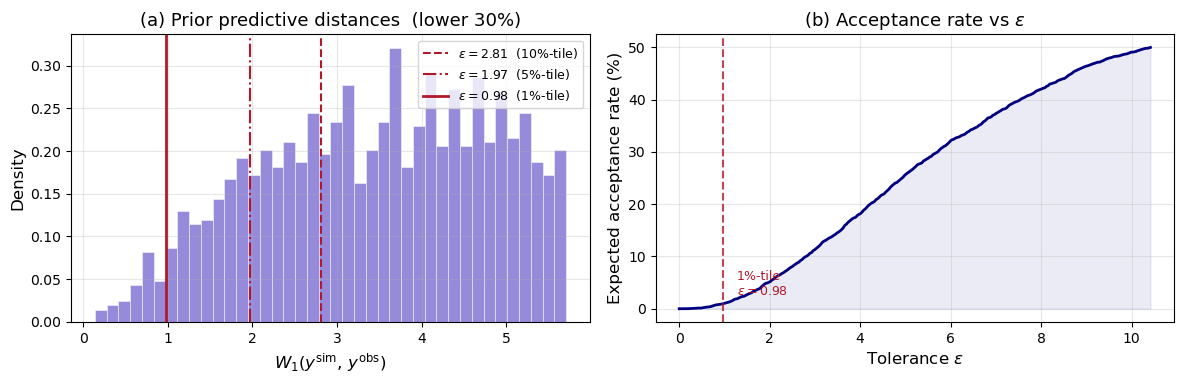

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) Histogram — zoom into the low-distance region where epsilon choices live
cutoff = np.quantile(calib_dists, 0.30)  # show only the left 30%
subset = calib_dists[calib_dists <= cutoff]
axes[0].hist(subset, bins=40, density=True, color="slateblue",
             edgecolor="white", alpha=0.7, linewidth=0.5)
for q, ls, lw in [(0.10, "--", 1.5), (0.05, "-.", 1.5), (0.01, "-", 2)]:
    axes[0].axvline(eps_table[q], ls=ls, lw=lw, color=C_RED,
                    label=fr"$\varepsilon={eps_table[q]:.2f}$  ({100*q:.0f}%-tile)")
axes[0].set_xlabel(r"$W_1(y^{\rm sim},\, y^{\rm obs})$")
axes[0].set_ylabel("Density")
axes[0].set_title(r"(a) Prior predictive distances  (lower 30%)")
axes[0].legend(fontsize=9, loc="upper right")

# (b) Acceptance rate curve
eps_grid = np.linspace(0, np.quantile(calib_dists, 0.50), 300)
acc_curve = np.array([(calib_dists <= e).mean() * 100 for e in eps_grid])
axes[1].plot(eps_grid, acc_curve, lw=2, color="navy")
axes[1].fill_between(eps_grid, acc_curve, alpha=0.08, color="navy")
# Mark the chosen epsilon
axes[1].axvline(eps_table[0.01], color=C_RED, ls="--", lw=1.5, alpha=0.8)
axes[1].annotate(f"1%-tile\n$\\varepsilon={eps_table[0.01]:.2f}$",
                 xy=(eps_table[0.01], 1.0), fontsize=9, color=C_RED,
                 ha="left", va="bottom",
                 xytext=(eps_table[0.01] + 0.3, 2))
axes[1].set_xlabel(r"Tolerance $\varepsilon$")
axes[1].set_ylabel("Expected acceptance rate (%)")
axes[1].set_title(r"(b) Acceptance rate vs $\varepsilon$")

plt.tight_layout()
plt.show()

As expected, most prior draws give large $W_1$ values — the distribution is heavily right-skewed. Only a small fraction of draws happen to produce parameters where the simulated data looks like $y^\star$.

From the right panel, at the 1% quantile ($\varepsilon \approx 0.98$), we'd need roughly 100 proposals per accepted draw. At the 0.5% quantile ($\varepsilon \approx 0.72$), that rises to about 200. Both are still computationally feasible for our setup, but the tighter tolerance is clearly more expensive.


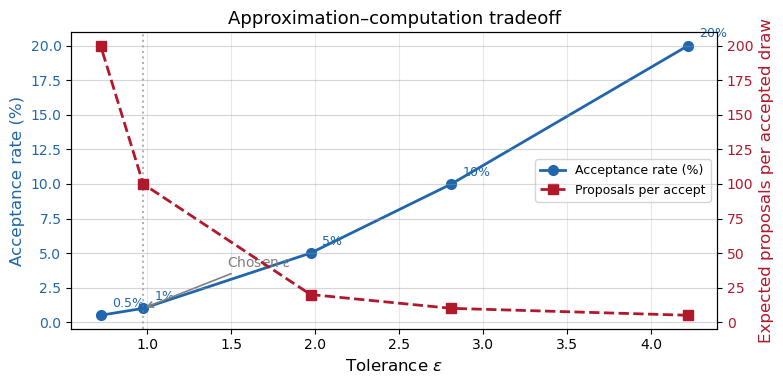

  Quantile   epsilon   Acc. rate   Cost/accept
----------------------------------------------
       20%     4.217      20.00%             5
       10%     2.810      10.00%            10
        5%     1.973       5.00%            20
        1%     0.977       1.00%           100
      0.5%     0.723       0.50%           200


In [8]:
# Compute acceptance rate and cost for a grid of epsilon values
eps_candidates = np.array([eps_table[q] for q in [0.20, 0.10, 0.05, 0.01, 0.005]])
q_labels = ["20%", "10%", "5%", "1%", "0.5%"]
acc_rates = np.array([(calib_dists <= e).mean() for e in eps_candidates])
cost_per_accept = 1.0 / acc_rates  # expected proposals per accepted draw

fig, ax1 = plt.subplots(figsize=(8, 4))

# Left axis: acceptance rate
ln1 = ax1.plot(eps_candidates, acc_rates * 100, "o-", color=C_BLUE, lw=2,
               ms=7, label="Acceptance rate (%)")
ax1.set_xlabel(r"Tolerance $\varepsilon$")
ax1.set_ylabel("Acceptance rate (%)", color=C_BLUE)
ax1.tick_params(axis="y", labelcolor=C_BLUE)

# Right axis: cost per accepted draw
ax2 = ax1.twinx()
ln2 = ax2.plot(eps_candidates, cost_per_accept, "s--", color=C_RED, lw=2,
               ms=7, label="Proposals per accept")
ax2.set_ylabel("Expected proposals per accepted draw", color=C_RED)
ax2.tick_params(axis="y", labelcolor=C_RED)

# Annotate each point with the quantile label
for e, q_lab, rate, cost in zip(eps_candidates, q_labels, acc_rates, cost_per_accept):
    ax1.annotate(q_lab, (e, rate * 100), textcoords="offset points",
                 xytext=(8, 6), fontsize=9, color=C_BLUE)

# Highlight the chosen epsilon
ax1.axvline(eps_table[0.01], color="gray", ls=":", lw=1.5, alpha=0.6)
ax1.annotate(r"Chosen $\varepsilon$", xy=(eps_table[0.01], acc_rates[3]*100),
             xytext=(eps_table[0.01] + 0.5, acc_rates[3]*100 + 3),
             fontsize=10, color="gray",
             arrowprops=dict(arrowstyle="->", color="gray", lw=1.2))

# Combined legend
lns = ln1 + ln2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, fontsize=9, loc="center right")

ax1.set_title(r"Approximation–computation tradeoff")
plt.tight_layout()
plt.show()

# Print table
print(f"{'Quantile':>10s}  {'epsilon':>8s}  {'Acc. rate':>10s}  {'Cost/accept':>12s}")
print("-" * 46)
for q_lab, e, rate, cost in zip(q_labels, eps_candidates, acc_rates, cost_per_accept):
    print(f"{q_lab:>10s}  {e:8.3f}  {100*rate:9.2f}%  {cost:12.0f}")

This plot makes the tradeoff concrete. The acceptance rate (blue, left axis) drops quickly as $\varepsilon$ shrinks, while the cost per accepted draw (red, right axis) grows fast.

Looking at the numbers: going from the 10% to the 1% quantile costs about 10$\times$ more proposals per accepted draw, but buys a large improvement in posterior concentration. Going further from 1% to 0.5% roughly doubles the cost again for a noticeably smaller gain.

So we go with the **1% quantile** ($\varepsilon = 0.9765$). In the main run, collecting 500 accepted draws takes about 49,000 proposals, which is still very manageable on a laptop. This makes the 1% level a reasonable compromise between approximation quality and computation time.


## Main Reject-ABC run

Let's run the algorithm with our chosen $\varepsilon$ and collect 500 accepted draws.

In [20]:
eps_main = eps_table[0.01]

accepted, dists_acc, n_prop, acc_rate = reject_abc(
    y_obs, L, epsilon=eps_main, n_keep=500,
    s=s0, t=t0, max_proposals=500_000, seed=2028
)

print(f"epsilon       = {eps_main:.4f}")
print(f"accepted      = {len(accepted)}")
print(f"proposals     = {n_prop}")
print(f"accept. rate  = {acc_rate:.4f}  ({100*acc_rate:.2f}%)")
print(f"correlation   = {np.corrcoef(accepted[:,0], accepted[:,1])[0,1]:.3f}")
print()
posterior_summary(accepted, true_values=[mu_true, sigma2_true])

epsilon       = 0.9765
accepted      = 500
proposals     = 49331
accept. rate  = 0.0101  (1.01%)
correlation   = -0.672



,parameter,mean,median,std,q2.5%,q97.5%,true
0,mu,-0.0749,-0.0834,0.0644,-0.1732,0.0586,0.0000
1,sigma2,0.2296,0.2344,0.0828,0.0675,0.3670,0.0900


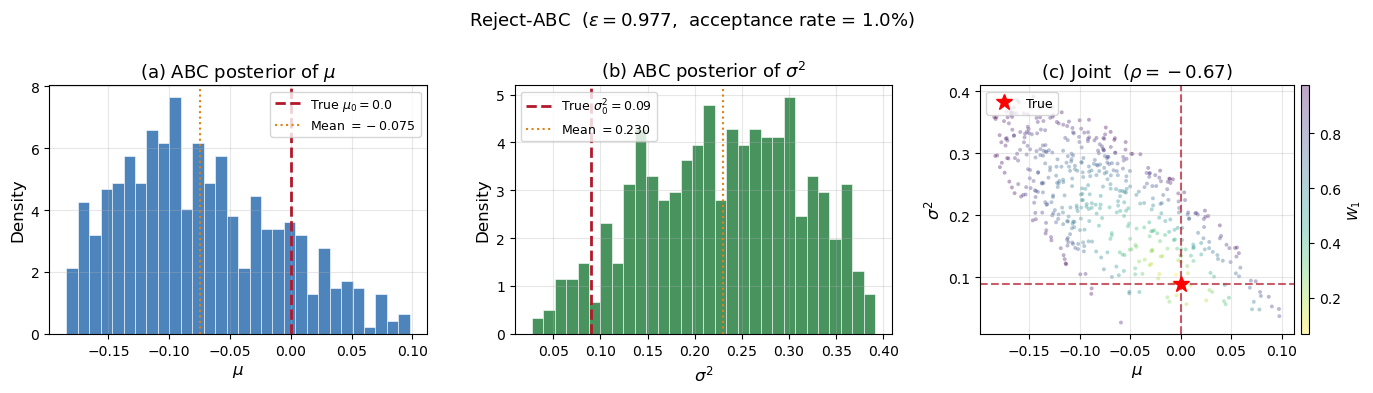

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# (a) mu
axes[0].hist(accepted[:, 0], bins=30, density=True, color=C_BLUE,
             edgecolor="white", alpha=0.8, linewidth=0.5)
axes[0].axvline(mu_true, color=C_RED, lw=2, ls="--", label=fr"True $\mu_0 = {mu_true}$")
axes[0].axvline(accepted[:, 0].mean(), color=C_ORANGE, lw=1.5, ls=":",
                label=fr"Mean $= {accepted[:, 0].mean():.3f}$")
axes[0].set_xlabel(r"$\mu$")
axes[0].set_ylabel("Density")
axes[0].set_title(r"(a) ABC posterior of $\mu$")
axes[0].legend(fontsize=9)

# (b) sigma^2
axes[1].hist(accepted[:, 1], bins=30, density=True, color=C_GREEN,
             edgecolor="white", alpha=0.8, linewidth=0.5)
axes[1].axvline(sigma2_true, color=C_RED, lw=2, ls="--",
                label=fr"True $\sigma_0^2 = {sigma2_true}$")
axes[1].axvline(accepted[:, 1].mean(), color=C_ORANGE, lw=1.5, ls=":",
                label=fr"Mean $= {accepted[:, 1].mean():.3f}$")
axes[1].set_xlabel(r"$\sigma^2$")
axes[1].set_ylabel("Density")
axes[1].set_title(r"(b) ABC posterior of $\sigma^2$")
axes[1].legend(fontsize=9)

# (c) joint
sc = axes[2].scatter(accepted[:, 0], accepted[:, 1], s=8, alpha=0.35,
                     c=dists_acc, cmap="viridis_r", edgecolors="none")
axes[2].axvline(mu_true, color=C_RED, ls="--", lw=1.5, alpha=0.7)
axes[2].axhline(sigma2_true, color=C_RED, ls="--", lw=1.5, alpha=0.7)
axes[2].plot(mu_true, sigma2_true, "r*", ms=12, zorder=5, label="True")
axes[2].set_xlabel(r"$\mu$")
axes[2].set_ylabel(r"$\sigma^2$")
axes[2].set_title(fr"(c) Joint  ($\rho = {np.corrcoef(accepted[:,0], accepted[:,1])[0,1]:.2f}$)")
axes[2].legend(fontsize=9, loc="upper left")
cb = plt.colorbar(sc, ax=axes[2], pad=0.02, aspect=30)
cb.set_label(r"$W_1$", fontsize=10)

plt.suptitle(fr"Reject-ABC  ($\varepsilon = {eps_main:.3f}$,  acceptance rate = {100*acc_rate:.1f}%)",
             fontsize=13)
plt.tight_layout()
plt.show()

Here's what we get with $\varepsilon = 0.9765$ (acceptance rate 1.01%, 49,331 proposals for 500 accepts):

For $\mu$, the posterior mean is $-0.0749$ with std $0.0644$. The 95% credible interval $[-0.1732,\; 0.0586]$ covers the true value $\mu_0 = 0$, but the distribution is still shifted slightly to the left. This is linked to the strong negative correlation $\rho = -0.672$ visible in the joint scatter plot: when $\sigma^2$ is overestimated, $\mu$ tends to be underestimated, because both parameters affect the overall scale of $Y_i$.

The more interesting result is $\sigma^2$: the posterior mean is $0.2296$, well above the true value $0.09$. The 95% interval $[0.0675,\; 0.3670]$ still covers the truth, but the distribution is clearly centered too high. This upward bias is largely a prior effect — our prior on $\log\sigma^2$ is centered at $\sigma^2 = 1$, which is far above the truth, and $\varepsilon = 0.98$ is not strict enough to overcome that pull.


## Effect of $\varepsilon$

Now let's see what happens when we vary $\varepsilon$. We run ABC at four tolerance levels (20%, 10%, 1%, and 0.5% quantiles) and compare the posteriors.

We expect smaller $\varepsilon$ to give more concentrated posteriors closer to the truth, but at the cost of lower acceptance rates.

In [22]:
eps_levels = [
    (0.20, "q=20%"),
    (0.10, "q=10%"),
    (0.01, "q=1%"),
    (0.005, "q=0.5%"),
]

eps_results = []
for j, (q, label) in enumerate(eps_levels):
    eps_val = eps_table[q]
    acc_j, _, nprop_j, rate_j = reject_abc(
        y_obs, L, epsilon=float(eps_val), n_keep=400,
        s=s0, t=t0, max_proposals=500_000, seed=3000 + j
    )
    eps_results.append({
        "quantile": label, "epsilon": eps_val,
        "n_accepted": len(acc_j), "n_proposals": nprop_j,
        "acc_rate": rate_j, "samples": acc_j,
    })

# Summary table
summary_rows = []
for r in eps_results:
    row = {
        "quantile": r["quantile"],
        "epsilon": f'{r["epsilon"]:.4f}',
        "accepted": r["n_accepted"],
        "proposals": r["n_proposals"],
        "acc. rate (%)": f'{100*r["acc_rate"]:.2f}',
    }
    if len(r["samples"]):
        row["E[mu]"] = f'{r["samples"][:, 0].mean():.4f}'
        row["E[sigma2]"] = f'{r["samples"][:, 1].mean():.4f}'
    else:
        row["E[mu]"] = chr(8212)
        row["E[sigma2]"] = chr(8212)
    summary_rows.append(row)

print(pd.DataFrame(summary_rows).to_string(index=False))

quantile epsilon  accepted  proposals acc. rate (%)   E[mu] E[sigma2]
   q=20%  4.2173       400       2137         18.72 -0.3669    0.6801
   q=10%  2.8105       400       4048          9.88 -0.2463    0.5219
    q=1%  0.9765       400      40573          0.99 -0.0723    0.2192
  q=0.5%  0.7232       400      71889          0.56 -0.0468    0.1805


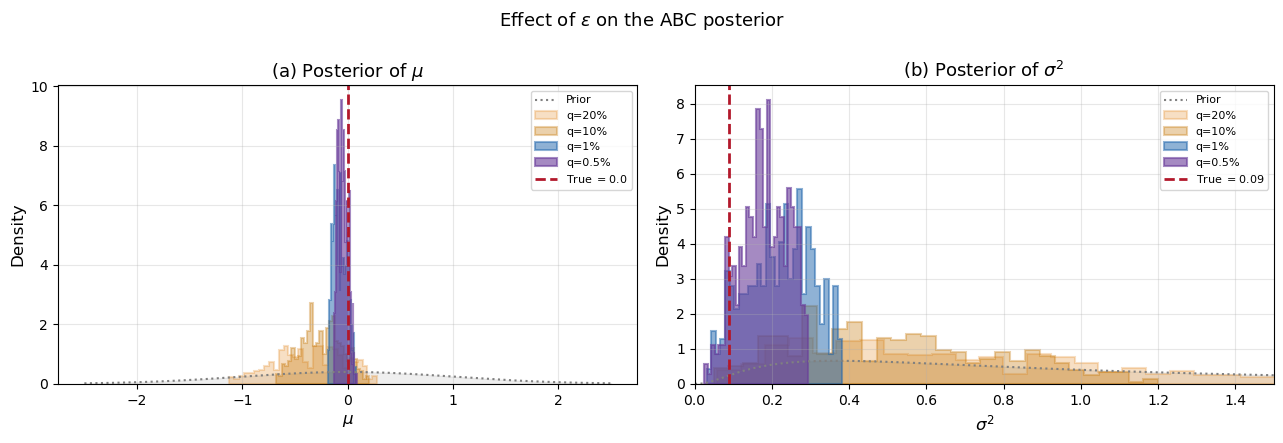

In [23]:
colors = [C_ORANGE, "#C77C11", C_BLUE, C_PURPLE]
alphas = [0.25, 0.35, 0.50, 0.60]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- (a) Posterior of mu ---
x_mu = np.linspace(-2.5, 2.5, 300)
prior_mu = (1 / (np.sqrt(2*np.pi) * s0)) * np.exp(-0.5 * (x_mu / s0)**2)
axes[0].fill_between(x_mu, prior_mu, alpha=0.12, color="gray")
axes[0].plot(x_mu, prior_mu, ":", color="gray", lw=1.5, label="Prior")
for r, c, a in zip(eps_results, colors, alphas):
    if len(r["samples"]):
        axes[0].hist(r["samples"][:, 0], bins=30, density=True, histtype="stepfilled",
                     alpha=a, color=c, edgecolor=c, lw=1.5, label=r["quantile"])
axes[0].axvline(mu_true, color=C_RED, lw=2, ls="--", label=fr"True $= {mu_true}$")
axes[0].set_xlabel(r"$\mu$")
axes[0].set_ylabel("Density")
axes[0].set_title(r"(a) Posterior of $\mu$")
axes[0].legend(fontsize=8)

# --- (b) Posterior of sigma^2 ---
x_s2 = np.linspace(0.001, 2.0, 400)
eta_pdf = (1 / (np.sqrt(2*np.pi) * t0)) * np.exp(-0.5 * (np.log(x_s2) / t0)**2)
prior_s2 = eta_pdf / x_s2
axes[1].fill_between(x_s2, prior_s2, alpha=0.12, color="gray")
axes[1].plot(x_s2, prior_s2, ":", color="gray", lw=1.5, label="Prior")
for r, c, a in zip(eps_results, colors, alphas):
    if len(r["samples"]):
        axes[1].hist(r["samples"][:, 1], bins=30, density=True, histtype="stepfilled",
                     alpha=a, color=c, edgecolor=c, lw=1.5, label=r["quantile"])
axes[1].axvline(sigma2_true, color=C_RED, lw=2, ls="--", label=fr"True $= {sigma2_true}$")
axes[1].set_xlim(0, 1.5)
axes[1].set_xlabel(r"$\sigma^2$")
axes[1].set_ylabel("Density")
axes[1].set_title(r"(b) Posterior of $\sigma^2$")
axes[1].legend(fontsize=8)

plt.suptitle(r"Effect of $\varepsilon$ on the ABC posterior", fontsize=13)
plt.tight_layout()
plt.show()

The results confirm what we expected. As $\varepsilon$ decreases, the posteriors shrink and shift toward the true values:

- At $\varepsilon = 4.22$ (20%-tile, rate 18.7%): $\hat{E}[\mu] = -0.3669$, $\hat{E}[\sigma^2] = 0.6801$ — still heavily influenced by the prior.
- At $\varepsilon = 2.81$ (10%-tile, rate 9.88%): $\hat{E}[\mu] = -0.2463$, $\hat{E}[\sigma^2] = 0.5219$.
- At $\varepsilon = 0.98$ (1%-tile, rate 0.99%): $\hat{E}[\mu] = -0.0723$, $\hat{E}[\sigma^2] = 0.2192$.
- At $\varepsilon = 0.72$ (0.5%-tile, rate 0.56%): $\hat{E}[\mu] = -0.0468$, $\hat{E}[\sigma^2] = 0.1805$.

So the bias on $\sigma^2$ goes $0.68 \to 0.52 \to 0.22 \to 0.18$ as we tighten $\varepsilon$. There's a large improvement between the 10% and 1% levels, but going from 1% to 0.5% only improves things modestly while making the run substantially more expensive.

Why does the bias persist even at $\varepsilon = 0.72$? Two reasons. First, any finite $\varepsilon > 0$ means we still accept parameters whose simulated data only *approximately* matches $y^\star$. Second, the prior on $\log\sigma^2$ is centered at $\sigma^2 = 1$, far above the truth, and keeps pulling the posterior upward. Even a strict tolerance cannot fully undo that. This motivates looking at whether a better prior helps (next section) or using MCMC-ABC to push $\varepsilon$ even lower.


## Sensitivity to the prior scales $s$ and $t$

The project asks us to discuss the impact of $s$ and $t$. We fix $\varepsilon$ at the 1% quantile and vary each one separately.

Our intuition going in: a wider prior wastes proposals in extreme regions (lower acceptance rate), while a tighter prior might not cover the true value (more bias). We expect $t$ to matter more than $s$, because the prior on $\log\sigma^2$ is centered at $\sigma^2 = 1$, which is far from the truth $\sigma^2 = 0.09$.

In [24]:
# --- Vary s (prior width on mu), keep t fixed ---
s_grid = [0.3, 1.0, 3.0]
s_runs = []
for j, s_try in enumerate(s_grid):
    acc_s, _, _, rate_s = reject_abc(
        y_obs, L, epsilon=eps_main, n_keep=300,
        s=s_try, t=t0, max_proposals=500_000, seed=4000 + j
    )
    s_runs.append((s_try, acc_s, rate_s))

# --- Vary t (prior width on log sigma^2), keep s fixed ---
t_grid = [0.3, 1.0, 3.0]
t_runs = []
for j, t_try in enumerate(t_grid):
    acc_t, _, _, rate_t = reject_abc(
        y_obs, L, epsilon=eps_main, n_keep=300,
        s=s0, t=t_try, max_proposals=500_000, seed=5000 + j
    )
    t_runs.append((t_try, acc_t, rate_t))

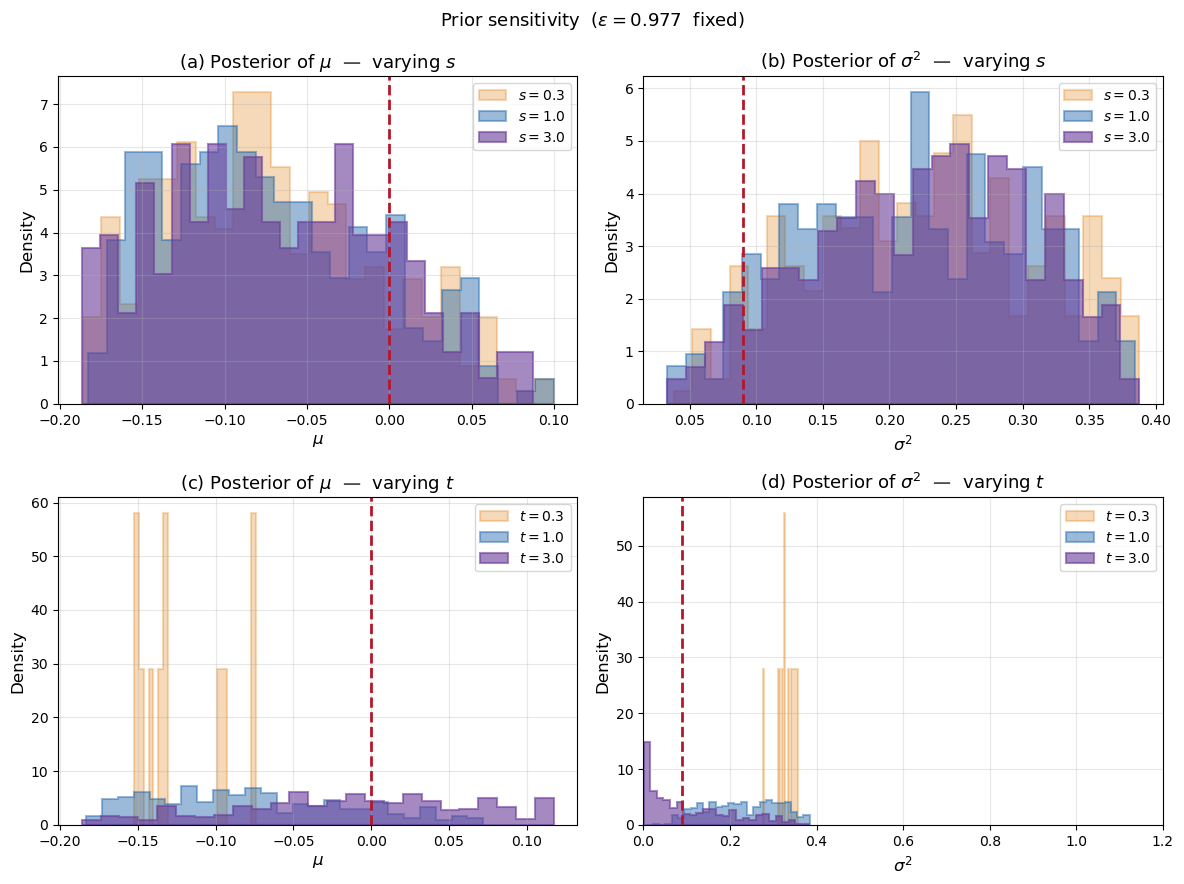

Acceptance rates:

  Varying s (t = 1.0 fixed):
    s = 0.3  =>  3.39%
    s = 1.0  =>  1.00%
    s = 3.0  =>  0.35%

  Varying t (s = 1.0 fixed):
    t = 0.3  =>  0.00%
    t = 1.0  =>  1.09%
    t = 3.0  =>  2.69%


In [25]:
cs = [C_ORANGE, C_BLUE, C_PURPLE]
alphas_ps = [0.30, 0.45, 0.60]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# ---- Row 1: varying s ----
for (s_try, acc_s, _), c, a in zip(s_runs, cs, alphas_ps):
    if len(acc_s):
        axes[0, 0].hist(acc_s[:, 0], bins=25, density=True, histtype="stepfilled",
                        alpha=a, color=c, edgecolor=c, lw=1.5, label=f"$s={s_try}$")
axes[0, 0].axvline(mu_true, color=C_RED, ls="--", lw=2)
axes[0, 0].set_title(r"(a) Posterior of $\mu$  —  varying $s$")
axes[0, 0].set_xlabel(r"$\mu$")
axes[0, 0].set_ylabel("Density")
axes[0, 0].legend()

for (s_try, acc_s, _), c, a in zip(s_runs, cs, alphas_ps):
    if len(acc_s):
        axes[0, 1].hist(acc_s[:, 1], bins=25, density=True, histtype="stepfilled",
                        alpha=a, color=c, edgecolor=c, lw=1.5, label=f"$s={s_try}$")
axes[0, 1].axvline(sigma2_true, color=C_RED, ls="--", lw=2)
axes[0, 1].set_title(r"(b) Posterior of $\sigma^2$  —  varying $s$")
axes[0, 1].set_xlabel(r"$\sigma^2$")
axes[0, 1].set_ylabel("Density")
axes[0, 1].legend()

# ---- Row 2: varying t ----
for (t_try, acc_t, _), c, a in zip(t_runs, cs, alphas_ps):
    if len(acc_t):
        axes[1, 0].hist(acc_t[:, 0], bins=25, density=True, histtype="stepfilled",
                        alpha=a, color=c, edgecolor=c, lw=1.5, label=f"$t={t_try}$")
axes[1, 0].axvline(mu_true, color=C_RED, ls="--", lw=2)
axes[1, 0].set_title(r"(c) Posterior of $\mu$  —  varying $t$")
axes[1, 0].set_xlabel(r"$\mu$")
axes[1, 0].set_ylabel("Density")
axes[1, 0].legend()

for (t_try, acc_t, _), c, a in zip(t_runs, cs, alphas_ps):
    if len(acc_t):
        axes[1, 1].hist(acc_t[:, 1], bins=25, density=True, histtype="stepfilled",
                        alpha=a, color=c, edgecolor=c, lw=1.5, label=f"$t={t_try}$")
axes[1, 1].axvline(sigma2_true, color=C_RED, ls="--", lw=2)
axes[1, 1].set_xlim(0, 1.2)
axes[1, 1].set_title(r"(d) Posterior of $\sigma^2$  —  varying $t$")
axes[1, 1].set_xlabel(r"$\sigma^2$")
axes[1, 1].set_ylabel("Density")
axes[1, 1].legend()

plt.suptitle(fr"Prior sensitivity  ($\varepsilon = {eps_main:.3f}$  fixed)", fontsize=13)
plt.tight_layout()
plt.show()

# Acceptance rates table
print("Acceptance rates:\n")
print(f"  Varying s (t = {t0:.1f} fixed):")
for s_try, _, rate in s_runs:
    print(f"    s = {s_try:.1f}  =>  {100*rate:.2f}%")
print(f"\n  Varying t (s = {s0:.1f} fixed):")
for t_try, _, rate in t_runs:
    print(f"    t = {t_try:.1f}  =>  {100*rate:.2f}%")

**Varying $s$ (width of the prior on $\mu$, with $t = 1$ fixed):**

Almost nothing changes. The posterior means are nearly identical across the three values: $\hat{E}[\mu]$ stays between about $-0.072$ and $-0.069$, while $\hat{E}[\sigma^2]$ stays between about $0.219$ and $0.227$. The main difference is the acceptance rate: 3.39% for $s = 0.3$, 1.00% for $s = 1.0$, and 0.35% for $s = 3.0$. A wider prior on $\mu$ mostly wastes proposals in extreme regions. Since the prior is centered at the true value $\mu_0 = 0$, widening it changes efficiency much more than bias.

**Varying $t$ (width of the prior on $\log\sigma^2$, with $s = 1$ fixed):**

This is where the important effect appears.

With $t = 0.3$, the algorithm essentially fails: only 11 draws are accepted out of 500,000 proposals (rate $\approx 0.0022\%$). The prior $\log\sigma^2 \sim \mathcal{N}(0, 0.09)$ is so concentrated around $\sigma^2 = 1$ that almost no mass reaches the true region near $\sigma^2 = 0.09$. The few accepted draws give $\hat{E}[\sigma^2] = 0.3314$, still heavily biased upward.

With $t = 3.0$, the results improve dramatically: $\hat{E}[\sigma^2] = 0.1059$, close to the true value $0.09$, and $\hat{E}[\mu] = -0.0122$, nearly unbiased. The acceptance rate also increases to 2.69%, compared with about 1.09% for $t = 1.0$. This is not a paradox: because the prior center ($\sigma^2 = 1$) is far from the truth, widening the prior actually puts *more* mass near the relevant region instead of wasting it.

**Bottom line:** the prior on $\log\sigma^2$ is the critical hyperparameter. With $t = 1$, there still is not enough prior mass near $\sigma^2 = 0.09$, which keeps the posterior biased upward. Using $t = 3$ largely fixes both the bias and the efficiency.


## Numerical error assessment

The project asks us to check the numerical error of our estimates. We do this by running Reject-ABC 20 times with different random seeds, keeping the same observed data and $\varepsilon$.

The variability across these runs tells us how much **Monte Carlo noise** there is in the algorithm, as opposed to the **systematic bias** from the ABC approximation.

In [26]:
n_repeats = 20
repeat_quantiles = [0.10, 0.01]

mu_box, s2_box, labels_box = [], [], []

for q in repeat_quantiles:
    eps_val = eps_table[q]
    mu_reps, s2_reps = [], []
    for r in range(n_repeats):
        acc_r, _, _, _ = reject_abc(
            y_obs, L, epsilon=float(eps_val), n_keep=200,
            s=s0, t=t0, max_proposals=300_000,
            seed=7000 + 100 * int(100 * q) + r
        )
        if len(acc_r) > 0:
            mu_reps.append(acc_r[:, 0].mean())
            s2_reps.append(acc_r[:, 1].mean())
    mu_box.append(mu_reps)
    s2_box.append(s2_reps)
    labels_box.append(f"q={100*q:.0f}%\n(" + chr(949) + f"={eps_val:.3f})")

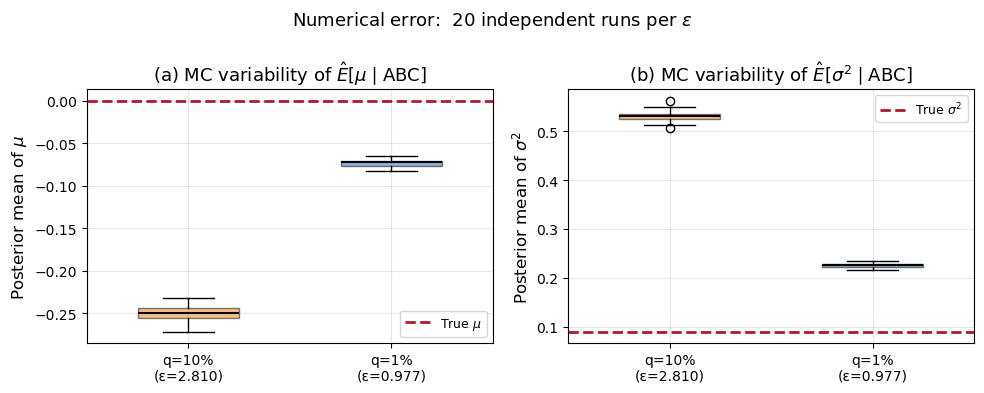

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

box_colors = [C_ORANGE, C_BLUE]

for ax, data, ylabel, param, true_val in [
    (axes[0], mu_box, r"Posterior mean of $\mu$", r"$\mu$", mu_true),
    (axes[1], s2_box, r"Posterior mean of $\sigma^2$", r"$\sigma^2$", sigma2_true),
]:
    bp = ax.boxplot(data, tick_labels=labels_box, patch_artist=True,
                    widths=0.5, medianprops=dict(color="black", lw=1.5))
    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)
    ax.axhline(true_val, color=C_RED, ls="--", lw=2, label=f"True {param}")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)

axes[0].set_title(r"(a) MC variability of $\hat{E}[\mu \mid \mathrm{ABC}]$")
axes[1].set_title(r"(b) MC variability of $\hat{E}[\sigma^2 \mid \mathrm{ABC}]$")

plt.suptitle(f"Numerical error:  {n_repeats} independent runs per $\\varepsilon$", fontsize=13)
plt.tight_layout()
plt.show()

The boxplots tell a clear story: the Monte Carlo variability (box width) is small compared with the ABC bias (distance from the box center to the red line).

The numbers confirm this. At the 10% quantile, the average posterior mean of $\sigma^2$ across the 20 runs is about $0.531$, so the bias is $+0.441$ relative to the true $0.09$, while the MC standard deviation is only $0.012$. At the 1% quantile, the average drops to about $0.226$, so the bias is smaller ($+0.136$), but it is still much larger than the MC standard deviation of $0.004$.

For $\mu$, the pattern is the same: the mean across repeated runs is about $-0.251$ at the 10% quantile and $-0.074$ at the 1% quantile, while the MC standard deviations are only $0.011$ and $0.005$, respectively.

So the estimates are very stable from run to run: changing the random seed barely changes the answer. The dominant error is systematic bias from the ABC approximation and the prior, not Monte Carlo noise. To reduce that bias, we would need either a smaller $\varepsilon$ or a better prior, such as $t = 3$, which we saw above moves the $\sigma^2$ posterior much closer to the truth.


## Posterior predictive check

As a final sanity check, we draw parameters from the ABC posterior, simulate new datasets under them, and compare them to the observed data. If the posterior is reasonable, the replicated datasets should look like $y^\star$.

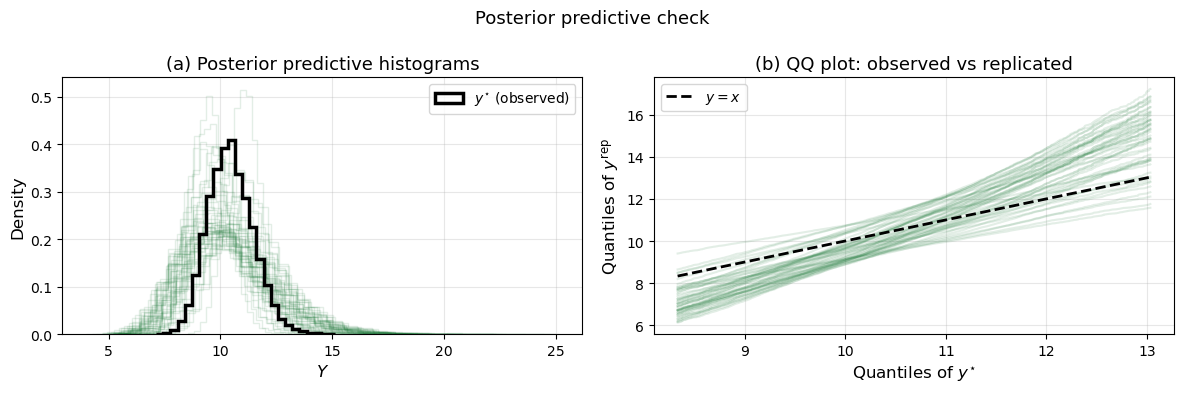

In [28]:
key_ppc = random.PRNGKey(2029)
n_rep = 50
key_ppc, subkey_idx = random.split(key_ppc)
idx = np.array(random.choice(subkey_idx, len(accepted), shape=(n_rep,), replace=True))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) Histogram overlay
for k in idx:
    key_ppc, subkey = random.split(key_ppc)
    y_rep = np.array(simulate_sum_lognormal(subkey, accepted[k, 0], accepted[k, 1], L, n))
    axes[0].hist(y_rep, bins=25, density=True, histtype="step",
                 color=C_GREEN, alpha=0.12)
axes[0].hist(y_obs, bins=25, density=True, histtype="step",
             color="black", lw=2.5, label=r"$y^{\star}$ (observed)")
axes[0].set_xlabel(r"$Y$")
axes[0].set_ylabel("Density")
axes[0].set_title("(a) Posterior predictive histograms")
axes[0].legend(fontsize=10)

# (b) QQ plot
q_grid = np.linspace(0.01, 0.99, n)
obs_q  = np.quantile(y_obs, q_grid)
key_ppc_qq = random.PRNGKey(2030)
for k in idx:
    key_ppc_qq, subkey = random.split(key_ppc_qq)
    y_rep = np.array(simulate_sum_lognormal(subkey, accepted[k, 0], accepted[k, 1], L, n))
    axes[1].plot(obs_q, np.quantile(y_rep, q_grid), color=C_GREEN, alpha=0.12)
lims = [obs_q.min(), obs_q.max()]
axes[1].plot(lims, lims, "k--", lw=2, label="$y = x$")
axes[1].set_xlabel(r"Quantiles of $y^{\star}$")
axes[1].set_ylabel(r"Quantiles of $y^{\rm rep}$")
axes[1].set_title("(b) QQ plot: observed vs replicated")
axes[1].legend(fontsize=10)

plt.suptitle("Posterior predictive check", fontsize=13)
plt.tight_layout()
plt.show()


The replicated datasets are clearly **more dispersed** than the observed data. In the histogram overlay, the green posterior-predictive curves are centered in roughly the right region, but they spread much more widely than the black observed histogram. The QQ plot shows the same phenomenon: the replicated quantiles lie below the diagonal in the lower tail and above it in the upper tail, which is the usual signature of overdispersion.

This makes sense. The ABC posterior still overestimates $\sigma^2$ (posterior mean $\approx 0.23$ versus the true value $0.09$), so posterior-predictive simulations are too variable. In the current run, the observed sample has standard deviation about $1.01$, while the average posterior-predictive standard deviation across the replicated datasets is about $1.64$.

So the PPC does flag a genuine problem: the ABC posterior is not yet fully consistent with the observed data. This is another view of the same issue already seen in the parameter estimates, namely the remaining upward bias in $\sigma^2$.


## Summary

Reject-ABC works reasonably well for this model. Even though the likelihood is intractable, we can simulate data easily and compare empirical distributions with the 1-Wasserstein distance.

**On $\varepsilon$:** there is a clear approximation-computation tradeoff. At the 20%-quantile ($\varepsilon = 4.22$), the posterior is still heavily biased, with $\hat{E}[\sigma^2] = 0.68$. At the 0.5%-quantile ($\varepsilon = 0.72$), this drops to $0.18$, but the acceptance rate also falls to about 0.56%. Most of the improvement happens between the 10% and 1% quantiles, which is why the 1% level ($\varepsilon = 0.98$) is a sensible default.

**On the prior:** the prior on $\mu$ (controlled by $s$) barely changes the posterior itself; it mainly changes efficiency. By contrast, the prior on $\log\sigma^2$ (controlled by $t$) is crucial. With $t = 1$, the prior center at $\sigma^2 = 1$ is too far from the true value $0.09$, which leaves a substantial upward bias ($\hat{E}[\sigma^2] \approx 0.23$). With $t = 3$, the posterior mean drops to about $0.106$ and the acceptance rate rises to about 2.69%, because the wider prior puts more mass near the truth.

**On numerical error:** repeated runs show that Monte Carlo variability is small relative to the ABC bias. The bottleneck is therefore the approximation itself, not simulation noise.

Overall, the notebook makes the right substantive point: Reject-ABC is workable here, but with the default prior it still overestimates $\sigma^2$. A tighter tolerance helps, and a better prior on $\log\sigma^2$ helps even more. The natural next step is MCMC-ABC, which should let us work at smaller effective tolerances more efficiently.
